# Day 1 — EDA

Load ERCOT hourly demand + Houston daily weather from the shared
`energy-text2sql` Postgres. Plot seasonality (annual, weekly, hourly) and
the demand-temperature relationship. The story before modeling.

## Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psycopg
import seaborn as sns
from dotenv import load_dotenv

load_dotenv(Path('..').resolve() / '.env', override=True)
DB_URL = os.environ['DATABASE_URL']

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.1f}'.format
print('DB:', DB_URL.split('@')[-1])

DB: localhost:5432/energy


## Load data

In [2]:
def load_demand() -> pd.DataFrame:
    q = """
        SELECT period AS ts, value AS demand_mwh
        FROM eia.demand
        WHERE region = 'ERCO'
        ORDER BY period
    """
    with psycopg.connect(DB_URL) as conn:
        df = pd.read_sql(q, conn)
    df['ts'] = pd.to_datetime(df['ts'], utc=True)
    return df

def load_weather() -> pd.DataFrame:
    q = """
        SELECT obs_date, tmax_c, tmin_c, prcp_mm, awnd_ms
        FROM noaa.daily_weather
        WHERE station_id = 'USW00012960'   -- Houston Hobby
        ORDER BY obs_date
    """
    with psycopg.connect(DB_URL) as conn:
        df = pd.read_sql(q, conn)
    df['obs_date'] = pd.to_datetime(df['obs_date']).dt.date
    return df

demand = load_demand()
weather = load_weather()
print(f'demand:  {len(demand):,} rows  ({demand.ts.min()} → {demand.ts.max()})')
print(f'weather: {len(weather):,} rows  ({weather.obs_date.min()} → {weather.obs_date.max()})')

demand:  43,847 rows  (2020-01-01 00:00:00+00:00 → 2024-12-31 23:00:00+00:00)
weather: 2,325 rows  (2020-01-01 → 2026-05-13)


/var/folders/cg/s1hky9z552j_pf1lxqv_qb600000gn/T/ipykernel_96633/3854839098.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn)
/var/folders/cg/s1hky9z552j_pf1lxqv_qb600000gn/T/ipykernel_96633/3854839098.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn)


## Basic stats

In [3]:
demand['demand_mwh'].describe()

count   43,847.0
mean    48,228.4
std     10,950.0
min     27,449.0
25%     40,351.5
50%     45,628.0
75%     53,965.5
max     85,544.0
Name: demand_mwh, dtype: float64

In [4]:
# Year-over-year totals — the 22% growth story
demand.assign(year=demand.ts.dt.year).groupby('year')['demand_mwh'].agg(['count', 'mean', 'sum'])

,count,mean,sum
year,,,
2020,8784,"43,370.1","380,963,260.0"
2021,8759,"44,813.2","392,518,489.0"
2022,8760,"49,159.2","430,634,261.0"
2023,8760,"51,003.9","446,793,938.0"
2024,8784,"52,796.3","463,762,563.0"


## Seasonality

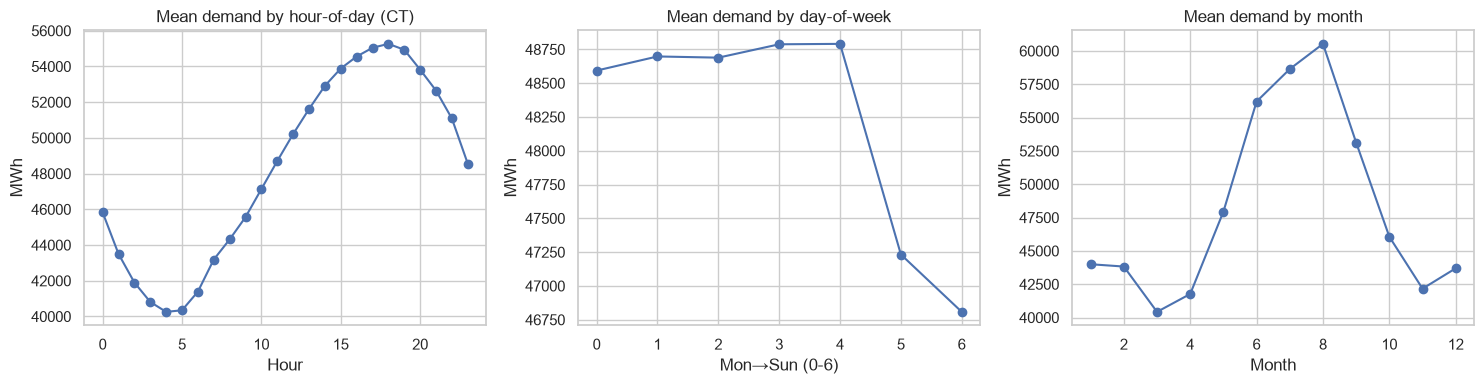

In [5]:
# Convert to Houston local time so 'hour-of-day' matches what residents experience
d = demand.copy()
d['ts_local'] = d['ts'].dt.tz_convert('America/Chicago')
d['hour']  = d['ts_local'].dt.hour
d['dow']   = d['ts_local'].dt.dayofweek   # 0=Mon ... 6=Sun
d['month'] = d['ts_local'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

d.groupby('hour')['demand_mwh'].mean().plot(ax=axes[0], marker='o')
axes[0].set_title('Mean demand by hour-of-day (CT)'); axes[0].set_xlabel('Hour'); axes[0].set_ylabel('MWh')

d.groupby('dow')['demand_mwh'].mean().plot(ax=axes[1], marker='o')
axes[1].set_title('Mean demand by day-of-week'); axes[1].set_xlabel('Mon→Sun (0-6)'); axes[1].set_ylabel('MWh')

d.groupby('month')['demand_mwh'].mean().plot(ax=axes[2], marker='o')
axes[2].set_title('Mean demand by month'); axes[2].set_xlabel('Month'); axes[2].set_ylabel('MWh')

plt.tight_layout()
plt.show()

## Demand vs temperature

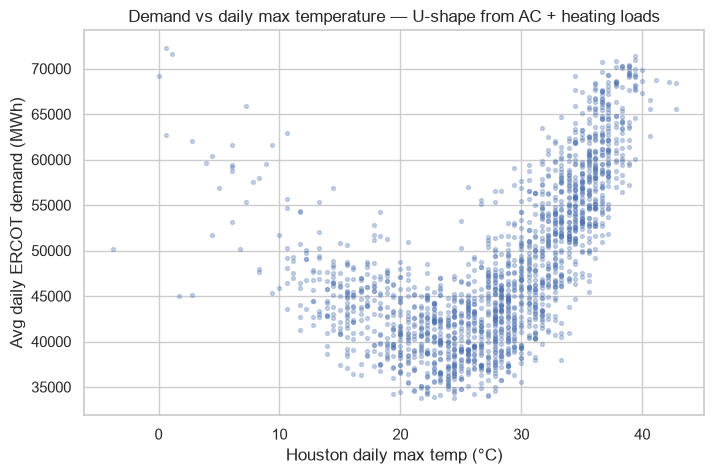

In [6]:
d['date'] = d['ts_local'].dt.date
daily = d.groupby('date', as_index=False)['demand_mwh'].mean()
joined = daily.merge(weather, left_on='date', right_on='obs_date').drop(columns='obs_date')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(joined['tmax_c'], joined['demand_mwh'], alpha=0.3, s=8)
ax.set_xlabel('Houston daily max temp (°C)')
ax.set_ylabel('Avg daily ERCOT demand (MWh)')
ax.set_title('Demand vs daily max temperature — U-shape from AC + heating loads')
plt.show()

## Takeaways for Day 2

- Strong **hour-of-day** pattern → calendar features matter.
- Lower **weekend** demand → day-of-week matters.
- Clear **annual cycle** with summer peak → month matters.
- Demand–temperature shows a **U-shape** (AC + heating loads) → temperature is a strong nonlinear predictor.
- Both ends of the temperature range matter — Feb 2021 freeze and Aug 2024 heat are edge cases the test set must include.